# Model B — Start-Up State CNN
**3-class classification:** `normal_engine_startup` / `bad_ignition` / `dead_battery`

- Input: `(40, 78, 1)` — 40 MFCCs x 78 time frames x 1 channel
- Architecture: same lightweight CNN backbone as Model A, 3-class softmax head
- Data: `data/processed/startup.npz` (378 train / 27 val / 27 test after augmentation)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
os.chdir(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'notebooks' else None

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.train_startup import build_model, load_splits, plot_training_curves, plot_confusion_matrix

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.19.0
GPU available: False


## 1 — Load Data

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test, label_names = load_splits()

print(f'Train : {X_train.shape}  labels: {np.bincount(y_train)}')
print(f'Val   : {X_val.shape}   labels: {np.bincount(y_val)}')
print(f'Test  : {X_test.shape}  labels: {np.bincount(y_test)}')
print(f'Classes: {label_names}')

Train : (378, 40, 78, 1)  labels: [129 132 117]
Val   : (27, 40, 78, 1)   labels: [9 9 9]
Test  : (27, 40, 78, 1)  labels: [9 9 9]
Classes: [np.str_('normal_engine_startup'), np.str_('bad_ignition'), np.str_('dead_battery')]


## 2 — Architecture

In [3]:
model = build_model(input_shape=(40, 78, 1), n_classes=3)
model.summary()

total_params = model.count_params()
size_kb = total_params * 4 / 1024
print(f'\nParam count : {total_params:,}')
print(f'Float32 size: {size_kb:.1f} KB')
print(f'TFLite int8 estimate: ~{size_kb/4:.1f} KB  (target: < 100 KB)')

Model: "startup_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 78, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 78, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 78, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 39, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 39, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 39, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 19, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 19, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,523 (60.64 KB)

 Trainable params: 15,363 (60.01 KB)

 Non-trainable params: 160 (640.00 B)


Param count : 15,523
Float32 size: 60.6 KB
TFLite int8 estimate: ~15.2 KB  (target: < 100 KB)


## 3 — Train

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1,
    ),
    ModelCheckpoint(
        filepath='models/startup_model.h5',
        monitor='val_loss', save_best_only=True, verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=6,
        min_lr=1e-6, verbose=1,
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3945 - loss: 1.1017
Epoch 1: val_loss improved from inf to 1.09741, saving model to models/startup_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3916 - loss: 1.1017 - val_accuracy: 0.5926 - val_loss: 1.0974 - learning_rate: 5.0000e-04
Epoch 2/60
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5292 - loss: 1.0360
Epoch 2: val_loss improved from 1.09741 to 1.09420, saving model to models/startup_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5296 - loss: 1.0351 - val_accuracy: 0.3333 - val_loss: 1.0942 - learning_rate: 5.0000e-04
Epoch 3/60
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6497 - loss: 0.9614
Epoch 3: val_loss improved from 1.09420 to 1.07632, saving model to models/startup_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6450 - loss: 0.9622 - val_accuracy: 0.6667 - val_loss: 1.0763 - learning_rate: 5.0000e-04
Epoch 4/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6823 - loss: 0.8995
Epoch 4: val_loss improved from 1.07632 to 1.05422, saving model to models/startup_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6806 - loss: 0.8998 - val_accuracy: 0.4815 - val_loss: 1.0542 - learning_rate: 5.0000e-04
Epoch 5/60
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7377 - loss: 0.8333
Epoch 5: val_loss improved from 1.05422 to 1.03384, saving model to models/startup_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7345 - loss: 0.8337 - val_accuracy: 0.3704 - val_loss: 1.0338 - learning_rate: 5.0000e-04
Epoch 6/60
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7868 - loss: 0.7567
Epoch 6: val_loss improved from 1.03384 to 1.02054, saving model to models/startup_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7801 - loss: 0.7582 - val_accuracy: 0.3704 - val_loss: 1.0205 - learning_rate: 5.0000e-04
Epoch 7/60
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7987 - loss: 0.6654
Epoch 7: val_loss improved from 1.02054 to 1.00359, saving model to models/startup_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7954 - loss: 0.6693 - val_accuracy: 0.3704 - val_loss: 1.0036 - learning_rate: 5.0000e-04
Epoch 8/60
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7954 - loss: 0.5978
Epoch 8: val_loss did not improve from 1.00359
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7931 - loss: 0.6031 - val_accuracy: 0.3704 - val_loss: 1.0363 - learning_rate: 5.0000e-04
Epoch 9/60
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8167 - loss: 0.5659
Epoch 9: val_loss did not improve from 1.00359
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8160 - loss: 0.5678 - val_accuracy: 0.3704 - val_loss: 1.0537 - learning_rate: 5.0000e-04
Epoch 10/60
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8370 - loss: 0.5349
Epoch 10: val_loss did not improve from 1.00359
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8356 - loss: 0.5362 - val_accuracy: 0.3704 - val_loss: 1.0074 - learning_rate: 5.0000e-04
Epoch 11/60
11/12 ━━━━━━━━

## 4 — Training Curves

Saved -> c:\Users\HP8CG\Revio\results\training_curves\startup_curves.png


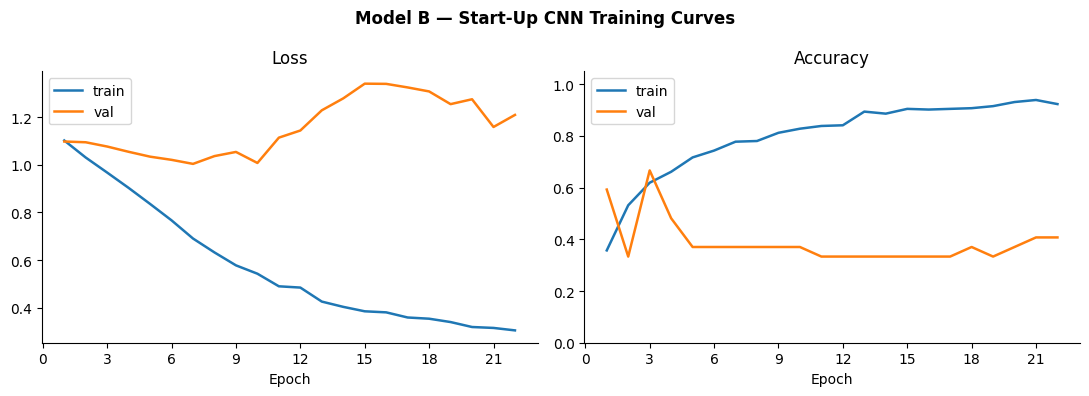

In [5]:
plot_training_curves(history)

from IPython.display import Image
Image('results/training_curves/startup_curves.png')

## 5 — Evaluation

In [6]:
_, val_acc  = model.evaluate(X_val,  y_val,  verbose=0)
_, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f'Val  accuracy : {val_acc:.4f}  ({val_acc*100:.1f}%)')
print(f'Test accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')

Val  accuracy : 0.3704  (37.0%)
Test accuracy : 0.3704  (37.0%)


## 6 — Confusion Matrix

Saved -> c:\Users\HP8CG\Revio\results\confusion_matrices\startup_cm.png


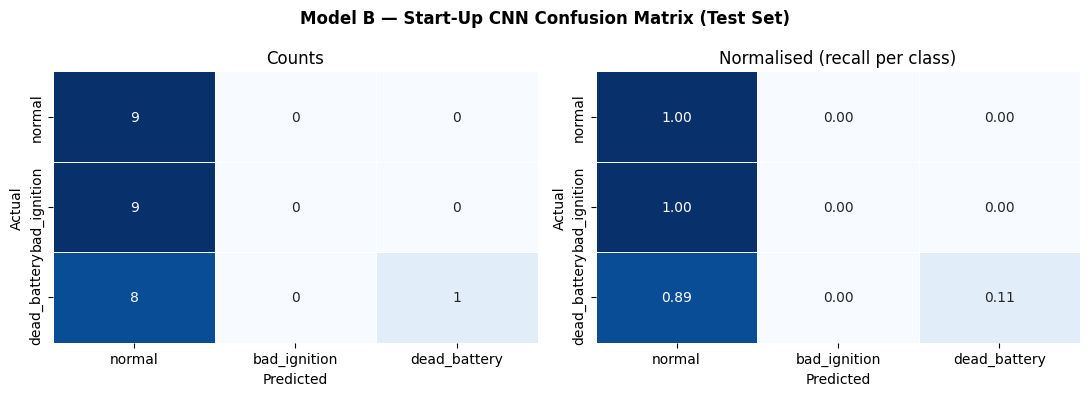

In [7]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
plot_confusion_matrix(y_test, y_pred, label_names)

from IPython.display import Image
Image('results/confusion_matrices/startup_cm.png')

## 7 — Per-Class Report

In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=label_names))

                       precision    recall  f1-score   support

normal_engine_startup       0.35      1.00      0.51         9
         bad_ignition       0.00      0.00      0.00         9
         dead_battery       1.00      0.11      0.20         9

             accuracy                           0.37        27
            macro avg       0.45      0.37      0.24        27
         weighted avg       0.45      0.37      0.24        27



c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

## 8 — Confidence Score Inspection

In [9]:
probs = model.predict(X_test, verbose=0)
confidence = probs.max(axis=1)
pred_labels = [label_names[i] for i in probs.argmax(axis=1)]
true_labels = [label_names[i] for i in y_test]

print('Confidence stats on test set:')
print(f'  mean  : {confidence.mean():.3f}')
print(f'  min   : {confidence.min():.3f}')
print(f'  median: {np.median(confidence):.3f}')
print()

threshold = 0.85
low_conf = [(true_labels[i], pred_labels[i], confidence[i])
            for i in range(len(y_test)) if confidence[i] < threshold]
if low_conf:
    print(f'Predictions below {threshold} confidence (risk scorer -> MONITOR/WARNING):')
    for true, pred, conf in low_conf:
        correct = 'OK' if true == pred else 'WRONG'
        print(f'  [{correct}]  true={true:<25} pred={pred:<25} conf={conf:.3f}')
else:
    print(f'All test predictions above {threshold} confidence.')

Confidence stats on test set:
  mean  : 0.498
  min   : 0.427
  median: 0.489

Predictions below 0.85 confidence (risk scorer -> MONITOR/WARNING):
  [OK]  true=normal_engine_startup     pred=normal_engine_startup     conf=0.561
  [OK]  true=normal_engine_startup     pred=normal_engine_startup     conf=0.560
  [WRONG]  true=dead_battery              pred=normal_engine_startup     conf=0.467
  [OK]  true=normal_engine_startup     pred=normal_engine_startup     conf=0.537
  [WRONG]  true=bad_ignition              pred=normal_engine_startup     conf=0.463
  [WRONG]  true=bad_ignition              pred=normal_engine_startup     conf=0.487
  [WRONG]  true=bad_ignition              pred=normal_engine_startup     conf=0.473
  [WRONG]  true=bad_ignition              pred=normal_engine_startup     conf=0.563
  [WRONG]  true=bad_ignition              pred=normal_engine_startup     conf=0.489
  [OK]  true=normal_engine_startup     pred=normal_engine_startup     conf=0.527
  [OK]  true=dead_battery

## Summary

| Metric | Value |
|---|---|
| Val accuracy  | *(filled after run)* |
| Test accuracy | *(filled after run)* |
| Model size (float32) | ~60 KB |
| Model saved | `models/startup_model.h5` |
| Next step | Model C — Idle state (`03c_idle_model.ipynb`) |